## 本文件用于数据预处理与预分析

## 数据处理：
- 实现了标签提取，统计标签次数，可视化标签分布

In [18]:
import json
import os

def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

In [19]:
# 标签统计
train_TAG_path="data/train_TAG.txt"
with open(train_TAG_path, "r", encoding="utf-8") as f:
    tags = f.read().split()   # 自动忽略空格、换行、分段
    
from collections import Counter 
label_set = sorted(set(tags))                 # 标签集
tag_count = Counter(tags)                     # 各标签频次
tag2id = {tag: idx for idx, tag in enumerate(label_set)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

print("标签总数：", len(tags))
print("标签集：", label_set)
print("各标签出现次数：", tag_count)
print("tag2id：", tag2id)


标签总数： 18974903
标签集： ['B_LOC', 'B_ORG', 'B_PER', 'B_T', 'I_LOC', 'I_ORG', 'I_PER', 'I_T', 'O']
各标签出现次数： Counter({'O': 17182664, 'I_T': 494698, 'I_PER': 352243, 'I_LOC': 326891, 'B_LOC': 206640, 'B_PER': 182664, 'B_T': 180819, 'I_ORG': 33203, 'B_ORG': 15081})
tag2id： {'B_LOC': 0, 'B_ORG': 1, 'B_PER': 2, 'B_T': 3, 'I_LOC': 4, 'I_ORG': 5, 'I_PER': 6, 'I_T': 7, 'O': 8}


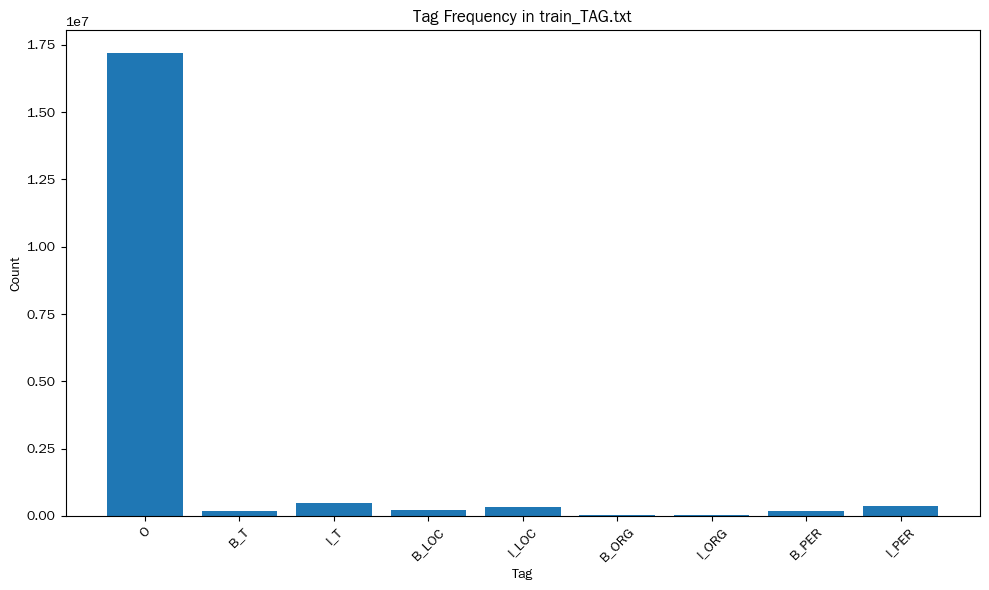

In [20]:
# 标签分布可视化
import matplotlib.pyplot as plt
# 取出标签名和对应频次
labels = list(tag_count.keys())
counts = list(tag_count.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.xlabel("Tag")
plt.ylabel("Count")
plt.title("Tag Frequency in train_TAG.txt")
plt.xticks(rotation=45)
plt.tight_layout()


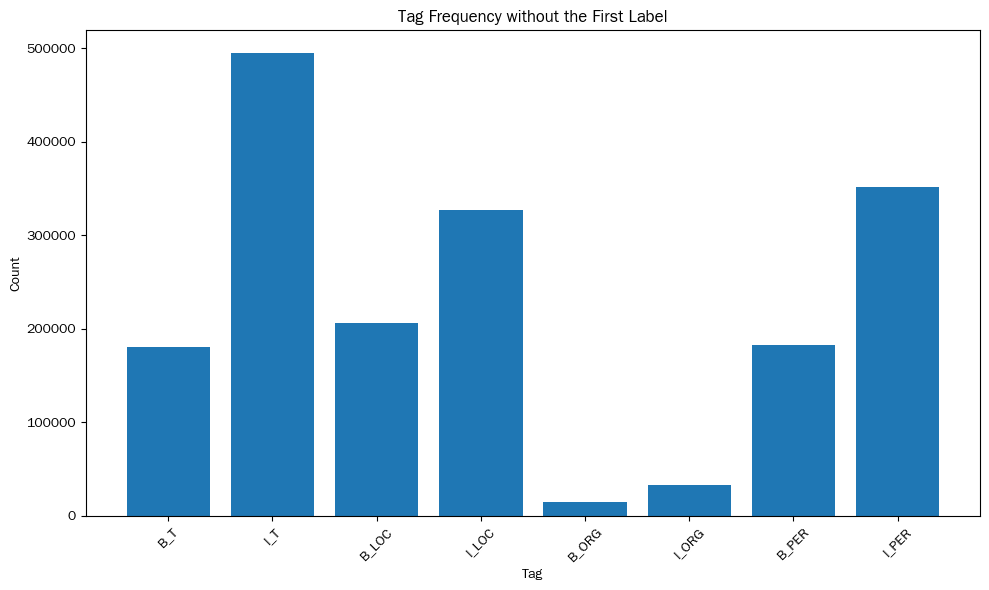

In [21]:
# O标签很多，影响对其他标签的相对比例观察，去除O后再次可视化
labels_2 = labels[1:]
counts_2 = counts[1:]

plt.figure(figsize=(10, 6))
plt.bar(labels_2, counts_2)
plt.xlabel("Tag")
plt.ylabel("Count")
plt.title("Tag Frequency without the First Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# 处理一下字符统计
# 说明：B表示begin，I表示in。B_T表示时间实体的开头，I_T表示时间实体内部字符。LOC表示地点实体（location），ORG表示机构实体（organization），PER表示人物实体（PERSON）
# 数据在txt中以行为基本单位，一行对应一个完整的句子
train_DATA_path="data/train.txt"
char_counter = Counter()

with open(train_DATA_path, "r", encoding="utf-8") as f:
    for line in f:
        chars = line.strip().split()
        char_counter.update(chars)

char2id = {
    "<PAD>": 0,
    "<UNK>": 1,
}

for ch, _ in char_counter.items():
    char2id[ch] = len(char2id)

id2char = {idx: ch for ch, idx in char2id.items()}
print(char2id)
print(id2char)


{'<PAD>': 0, '<UNK>': 1, '人': 2, '民': 3, '网': 4, '1': 5, '月': 6, '日': 7, '讯': 8, '据': 9, '《': 10, '纽': 11, '约': 12, '时': 13, '报': 14, '》': 15, '道': 16, ',': 17, '美': 18, '国': 19, '华': 20, '尔': 21, '街': 22, '股': 23, '市': 24, '在': 25, '2': 26, '0': 27, '3': 28, '年': 29, '的': 30, '最': 31, '后': 32, '一': 33, '天': 34, '继': 35, '续': 36, '上': 37, '涨': 38, '和': 39, '全': 40, '球': 41, '样': 42, '都': 43, '以': 44, '高': 45, '纪': 46, '录': 47, '或': 48, '接': 49, '近': 50, '结': 51, '束': 52, '本': 53, '交': 54, '易': 55, '。': 56, '说': 57, '标': 58, '普': 59, '5': 60, '指': 61, '数': 62, '今': 63, '升': 64, '9': 65, '.': 66, '6': 67, '%': 68, '为': 69, '7': 70, '来': 71, '大': 72, '幅': 73, ';': 74, '琼': 75, '斯': 76, '工': 77, '业': 78, '平': 79, '均': 80, '纳': 81, '达': 82, '克': 83, '8': 84, '就': 85, '由': 86, '于': 87, '前': 88, '景': 89, '看': 90, '好': 91, '经': 92, '济': 93, '增': 94, '长': 95, '明': 96, '可': 97, '能': 98, '加': 99, '速': 100, '消': 101, '费': 102, '者': 103, '信': 104, '心': 105, '商': 106, '协': 107, '进': 108, '会': 109, '

In [ ]:
save_json(char2id, "meta/char2id.json")
save_json(id2char, "meta/id2char.json")
save_json(tag2id, "meta/tag2id.json")
save_json(id2tag, "meta/id2tag.json")
## 存储为文件，方便后续使用

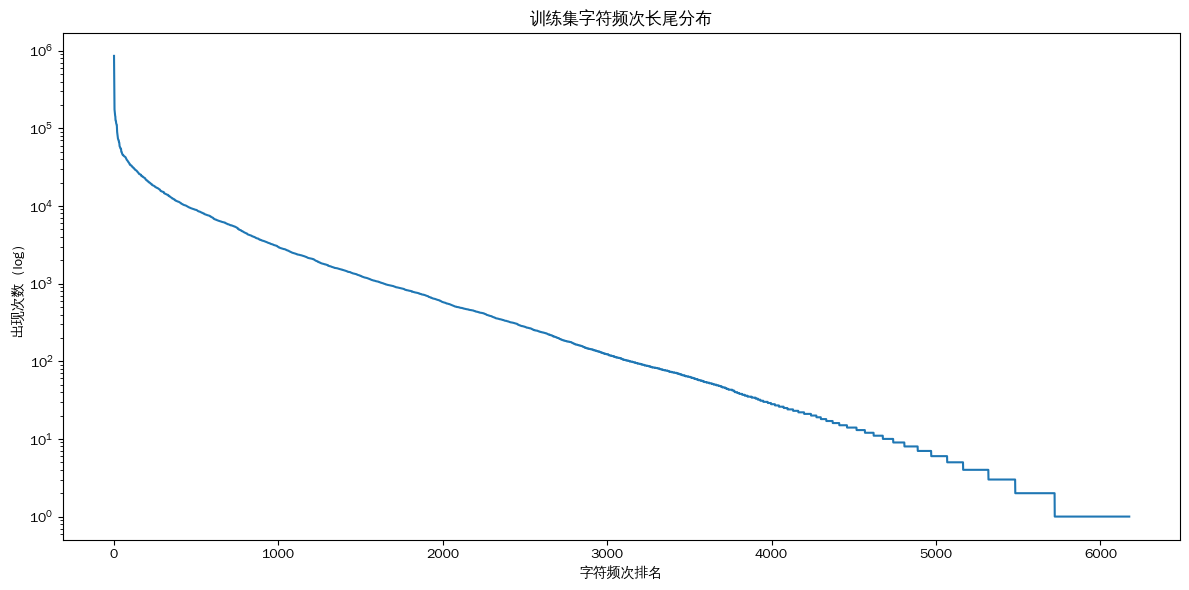

In [ ]:
# 字符分布可视化
# 取前 topk 个高频字符
topk = 6177
most_common_chars = char_counter.most_common(topk)

chars = [x[0] for x in most_common_chars]
counts = [x[1] for x in most_common_chars]

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
# 或
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC"]
# 或
plt.rcParams["font.sans-serif"] = ["WenQuanYi Zen Hei"]
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(counts) + 1), counts)
plt.yscale("log")
plt.xlabel("字符频次排名")
plt.ylabel("出现次数（log）")
plt.title("训练集字符频次分布")
plt.tight_layout()
plt.show()

In [ ]:
## 分析句子长度分布
train_DATA_path = "data/train.txt"
sent_lens = []

with open(train_DATA_path, "r", encoding="utf-8") as f:
    for line in f:
        chars = line.strip().split()
        if not chars:
            continue  # 跳过空行
        sent_lens.append(len(chars))

# -------------------------
# 2. 句子长度分布分析
# -------------------------
import numpy as np
sent_lens = np.array(sent_lens)

print("\n===== 句子长度统计 =====")
print("句子总数:", len(sent_lens))
print("最短句长:", sent_lens.min())
print("最长句长:", sent_lens.max())
print("平均句长:", sent_lens.mean())
print("中位数句长:", np.median(sent_lens))

for p in [50, 75, 90, 95, 99]:
    print(f"P{p} 句长:", np.percentile(sent_lens, p))

# -------------------------
# 3. 按区间看分布
# -------------------------
bins = [0, 10, 20, 30, 50, 100, 200, 500, 1000]
hist, bin_edges = np.histogram(sent_lens, bins=bins)

print("\n===== 句长区间分布 =====")
for i in range(len(hist)):
    left = bin_edges[i] + 1
    right = bin_edges[i + 1]
    print(f"{int(left):>4} ~ {int(right):>4}: {hist[i]}")

# -------------------------
# 4. 给后面模型选 max_len 参考
# -------------------------
max_len_95 = int(np.percentile(sent_lens, 95))
max_len_99 = int(np.percentile(sent_lens, 99))

print("\n===== max_len 参考 =====")
print("覆盖95%句子的长度:", max_len_95)
print("覆盖99%句子的长度:", max_len_99)

# 若你后面想直接采用“训练集最大句长”
recommended_max_len = int(sent_lens.max())
print("训练集最大句长:", recommended_max_len)

词表大小: 6177
前10个char2id示例: [('<PAD>', 0), ('<UNK>', 1), ('人', 2), ('民', 3), ('网', 4), ('1', 5), ('月', 6), ('日', 7), ('讯', 8), ('据', 9)]

===== 句子长度统计 =====
句子总数: 230039
最短句长: 1
最长句长: 1511
平均句长: 82.48559157360273
中位数句长: 73.0
P50 句长: 73.0
P75 句长: 118.0
P90 句长: 168.0
P95 句长: 207.0
P99 句长: 307.0

===== 句长区间分布 =====
   1 ~   10: 21512
  11 ~   20: 26323
  21 ~   30: 20117
  31 ~   50: 18336
  51 ~  100: 64539
 101 ~  200: 66145
 201 ~  500: 12806
 501 ~ 1000: 249

===== max_len 参考 =====
覆盖95%句子的长度: 207
覆盖99%句子的长度: 307
训练集最大句长: 1511
